In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:

n_features = 2

X = []
y = []

Xb = np.random.uniform(low=0.0, high=10.0, size=(900, n_features))
Xs = np.random.normal(loc=5.0, scale=0.5, size=(100, n_features))

Xb_sigregion = Xb[:450] 
Xb_backregion = Xb[450:]

# signal region
X_sigregion = np.vstack((Xb_sigregion, Xs))
y_sigregion = np.ones(len(X_sigregion)) 

# pure background region
X_backregion = Xb_backregion
y_backregion = np.zeros(len(X_backregion))

X_weak = np.vstack((X_sigregion, X_backregion))
y_weak = np.concatenate((y_sigregion, y_backregion))



X_train, X_val, y_train, y_val = train_test_split(X_weak, y_weak, test_size=0.2)



# Generate fresh testing data
X_test_bg = np.random.uniform(low=0.0, high=10.0, size=(180, n_features))
y_test_bg = np.zeros(180) # TRUE label: 0

X_test_sig = np.random.normal(loc=5.0, scale=0.5, size=(20, n_features))
y_test_sig = np.ones(20) # TRUE label: 1

# Combine them
X_test = np.vstack((X_test_bg, X_test_sig))
y_test = np.concatenate((y_test_bg, y_test_sig))


print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 800 events.
Validation set has 200 events.
Test set has 200 events.


           p1        p2  weak label
0    8.549362  4.088645         1.0
1    0.337806  4.848320         1.0
2    1.171889  6.129761         1.0
3    5.223050  3.764421         1.0
4    2.549479  0.439732         1.0
..        ...       ...         ...
995  5.788419  0.396295         0.0
996  7.544431  1.749674         0.0
997  6.110337  2.749070         0.0
998  5.994441  0.958289         0.0
999  8.561270  4.205474         0.0

[1000 rows x 3 columns]


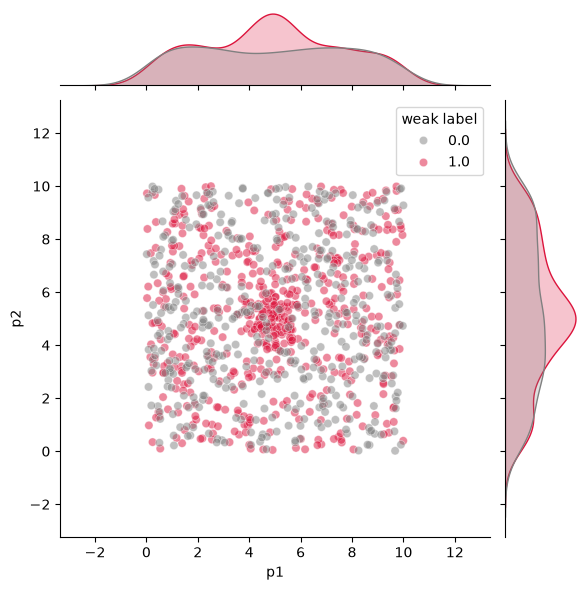

In [3]:
df = pd.DataFrame(np.column_stack([X_weak,y_weak]), columns = ["p1", "p2", "weak label"])
print(df)

# This creates a scatter plot in the middle, but adds density curves (the peaks!) on the top and side axes
sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [4]:
### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_scaled = scaler.fit_transform(X_train)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

Train mean (before scaling): [4.9362002  5.13804574]
Train mean (after scaling) -- each dimension should be close to 0: [ 1.47937218e-16 -5.01820807e-16]
Train std (before scaling) [2.79177823 2.67106234]
Train std (after scaling) -- each dimension should be close to 1: [1. 1.]


In [5]:
X_train_scaled_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_val_scaled_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

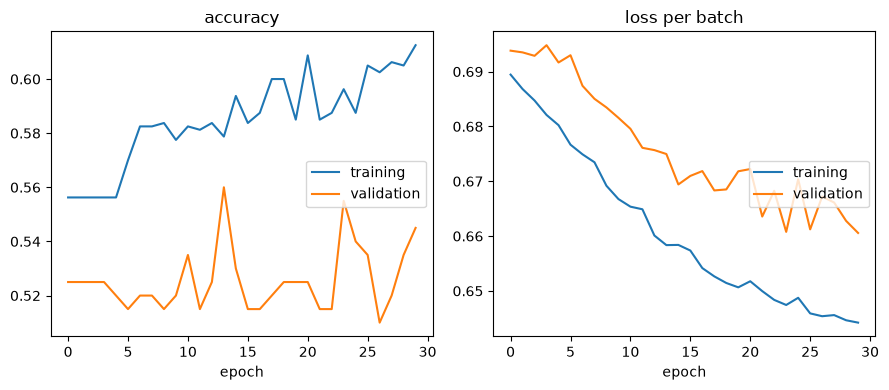

accuracy
	training         	 (min:    0.556, max:    0.613, cur:    0.613)
	validation       	 (min:    0.510, max:    0.560, cur:    0.545)
loss per batch
	training         	 (min:    0.644, max:    0.689, cur:    0.644)
	validation       	 (min:    0.661, max:    0.695, cur:    0.661)
Epoch 29, Loss: 0.6669420003890991


In [6]:
# training loop and plots

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim1 = 32, hidden_dim2 = 32, hidden_dim3 = 32, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                           ## add dropout layers?? HERE !!!! -------
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# NOTE: with only 2 input features and 800 training events, 256-unit hidden layers
# (~136k params) badly overparameterize the problem -- that's what was making the
# loss/accuracy curves noisy instead of converging. 32 units/layer is plenty here.
model = NeuralNetwork(input_dim = 2, hidden_dim1 = 32, hidden_dim2 = 32, hidden_dim3 = 32, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

n_epochs = 30

for epoch in range(n_epochs):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device).float(), labels.to(device).float()
        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    out_values = []
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        out_values.extend(out.detach().numpy())
        loss = loss_fn(out.squeeze(), labels)  # compute loss
        total_val_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()        
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

Average test loss: 0.7166 | Test accuracy: 0.530
Test ROC-AUC (vs true labels): 0.984  (0.5 = no separation, 1.0 = perfect)


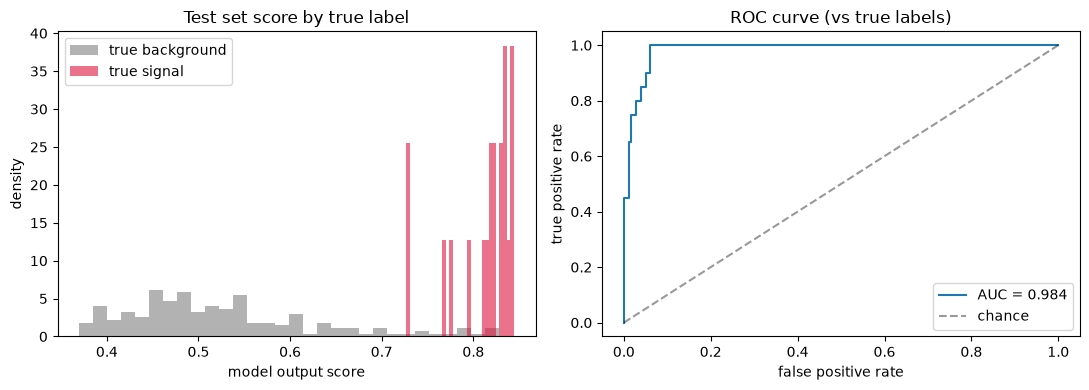

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out.squeeze(), labels)
        test_loss += loss.item() * inputs.size(0)

        # BUG FIX: out is a sigmoid output in [0,1], so the decision threshold
        # must be 0.5 (matching train/val), not 0.0. ">= 0.0" was always true,
        # which silently predicted "signal" for every event.
        predicted = (out.squeeze() >= 0.5).float()

        all_scores.extend(out.squeeze().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# Test set is imbalanced (180 background / 20 signal), so plain accuracy is
# dominated by the majority class and can look "fine" even when the model has
# learned nothing. ROC-AUC on the TRUE labels is the metric that actually
# answers "did weak supervision recover true signal/background separation?"
auc = roc_auc_score(all_labels, all_scores)
print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Score distribution split by TRUE label -- the key weak-supervision diagnostic.
# If training on region labels worked, these two histograms should separate
# even though the model never saw true signal/background labels during training.
axes[0].hist(all_scores[all_labels == 0], bins=30, alpha=0.6, label="true background", color="grey", density=True)
axes[0].hist(all_scores[all_labels == 1], bins=30, alpha=0.6, label="true signal", color="crimson", density=True)
axes[0].set_xlabel("model output score")
axes[0].set_ylabel("density")
axes[0].set_title("Test set score by true label")
axes[0].legend()

fpr, tpr, _ = roc_curve(all_labels, all_scores)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (vs true labels)")
axes[1].legend()

plt.tight_layout()
plt.show()